# **Práctica 1**: *Minería de Textos y Análisis de Sentimientos*
 **Asignatura**: Minería de Textos y Modelos de Lenguaje

<div style="display: flex; justify-content: space-between; align-items: center; width: 100%;"> <div> <img src="../logo_uclm.png" alt="Logo UCLM" width="300"> </div> <div style="text-align: right;"> <strong>Autores:</strong><br> Antonio Carrascosa Jiménez<br> Iván Román Utrilla </div> </div>

## ****Introducción****

En esta práctica abordamos un flujo completo de Minería de Textos y Análisis de Sentimientos aplicado a un conjunto de datos compuesto por t etiquetados con polaridad positiva o negativa.

Se entrenarán y evaluarán distintos modelos de clasificación supervisada utilizando tanto un esquema de validación por retención (80/20) como validación cruzada estratificada. Finalmente, se analizará el rendimiento de los modelos, la influencia de las decisiones de preprocesamiento y la estabilidad de los resultados.


## ****0. Preparativos****
Comenzaremos cargando todas las librerías que serán necesarias durante el desarrollo de la práctica. También, se fijará una semilla para la reproducibilidad del entrenamiento de los modelos.

In [1]:
import pandas as pd
import numpy as np
import spacy
import limpieza_canonica
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from collections import Counter
import seaborn as sns
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
seed = 42

## ****1. Carga y preparación inicial del conjunto de datos****
En este primer apartado cargaremos el conjunto de datos dado a partir de un csv utilizando pandas. Seguidamente, seleccionaremos aquellas variables con las cuales trabajaremos (`text` y `polarity`) y las convertiremos en una *serie*. Adicionalmente, aplicamos una transformación a la variable `polarity`:
- "negativo": 0
- "positivo": 1

Por último, mostraremos una gráfica que nos permitirá analizar el desbalanceo de la variable objetivo, para determinar si una validación estratificada es coherente para el problema.

In [2]:
df_original = pd.read_csv("sentiment_analysis_dataset_polarity.csv")

corpus_text = df_original["text"] # Variable de texto a utilizar para el análisis de sentimiento
polarity = df_original["polarity"] # Variable objetivo

polarity = polarity.map({"negativo": 0, "positivo": 1})

df_procesado = pd.DataFrame({ "text": corpus_text, "polarity": polarity }) 
df_procesado.sample(10, random_state=seed)

,text,polarity
1179,Extraño esa figura en la casa que estaba atent...,1
1204,"ni modo, tocó independizarse rápido",1
2576,"A los de JxC, y ""Periodistas"" que estan defend...",1
422,Después de varios comentarios agrios y hate re...,0
695,"no me extraña que se hayan alejado amistades, ...",0
194,"Hay varias pero, pq sigo sintiéndome infeliz, ...",0
296,Gordo Dan me parece un tipo asquerosamente fac...,0
1554,"una pena lo de oklahoma, revivieron muy muy ta...",1
1210,Que tiene como casi dos horas viéndose la espa...,1
173,Me regalaron dos rosas bonitas 💕 fue muy bonit...,0


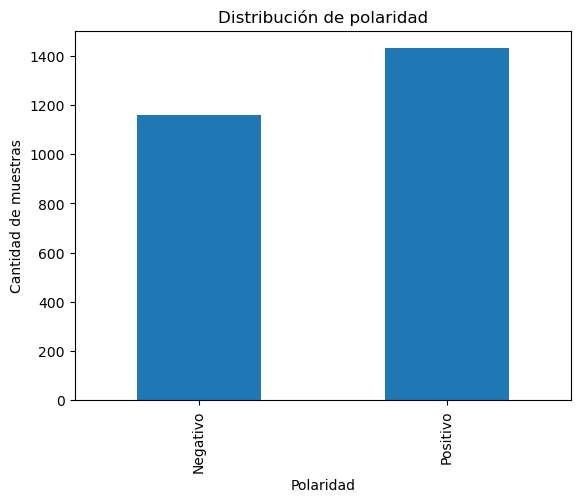

Difencia de  23.275862068965516 % entre negativos y positivos


In [3]:
counts = df_procesado["polarity"].value_counts(ascending = True)

counts.plot(kind="bar")
plt.title("Distribución de polaridad")
plt.xlabel("Polaridad")
plt.ylabel("Cantidad de muestras")
plt.xticks(ticks=[0, 1], labels=["Negativo", "Positivo"])
plt.show()

dif = (counts[1]-counts[0])/counts[0]

print("Difencia de ",dif*100, "% entre negativos y positivos")

Como podemos apreciar en la gráfica y en el resultado del cálculo, la diferencia en la cantidad de registros entre ambas etiquetas es superior al 20%, por lo que aplicar validación estratificada es muy recomendable.

## ****2. Preprocesado y limpieza del texto****

En este segundo apartado, relizaremos la limpieza de datos necesaria y usaremos `spacy` para analizar las palabras vacías (*stop_words*) que componen nuestro conjunto de datos. Primeramente, ahoremos un estudio sobre las palabras vacías que posee la variable `text`...

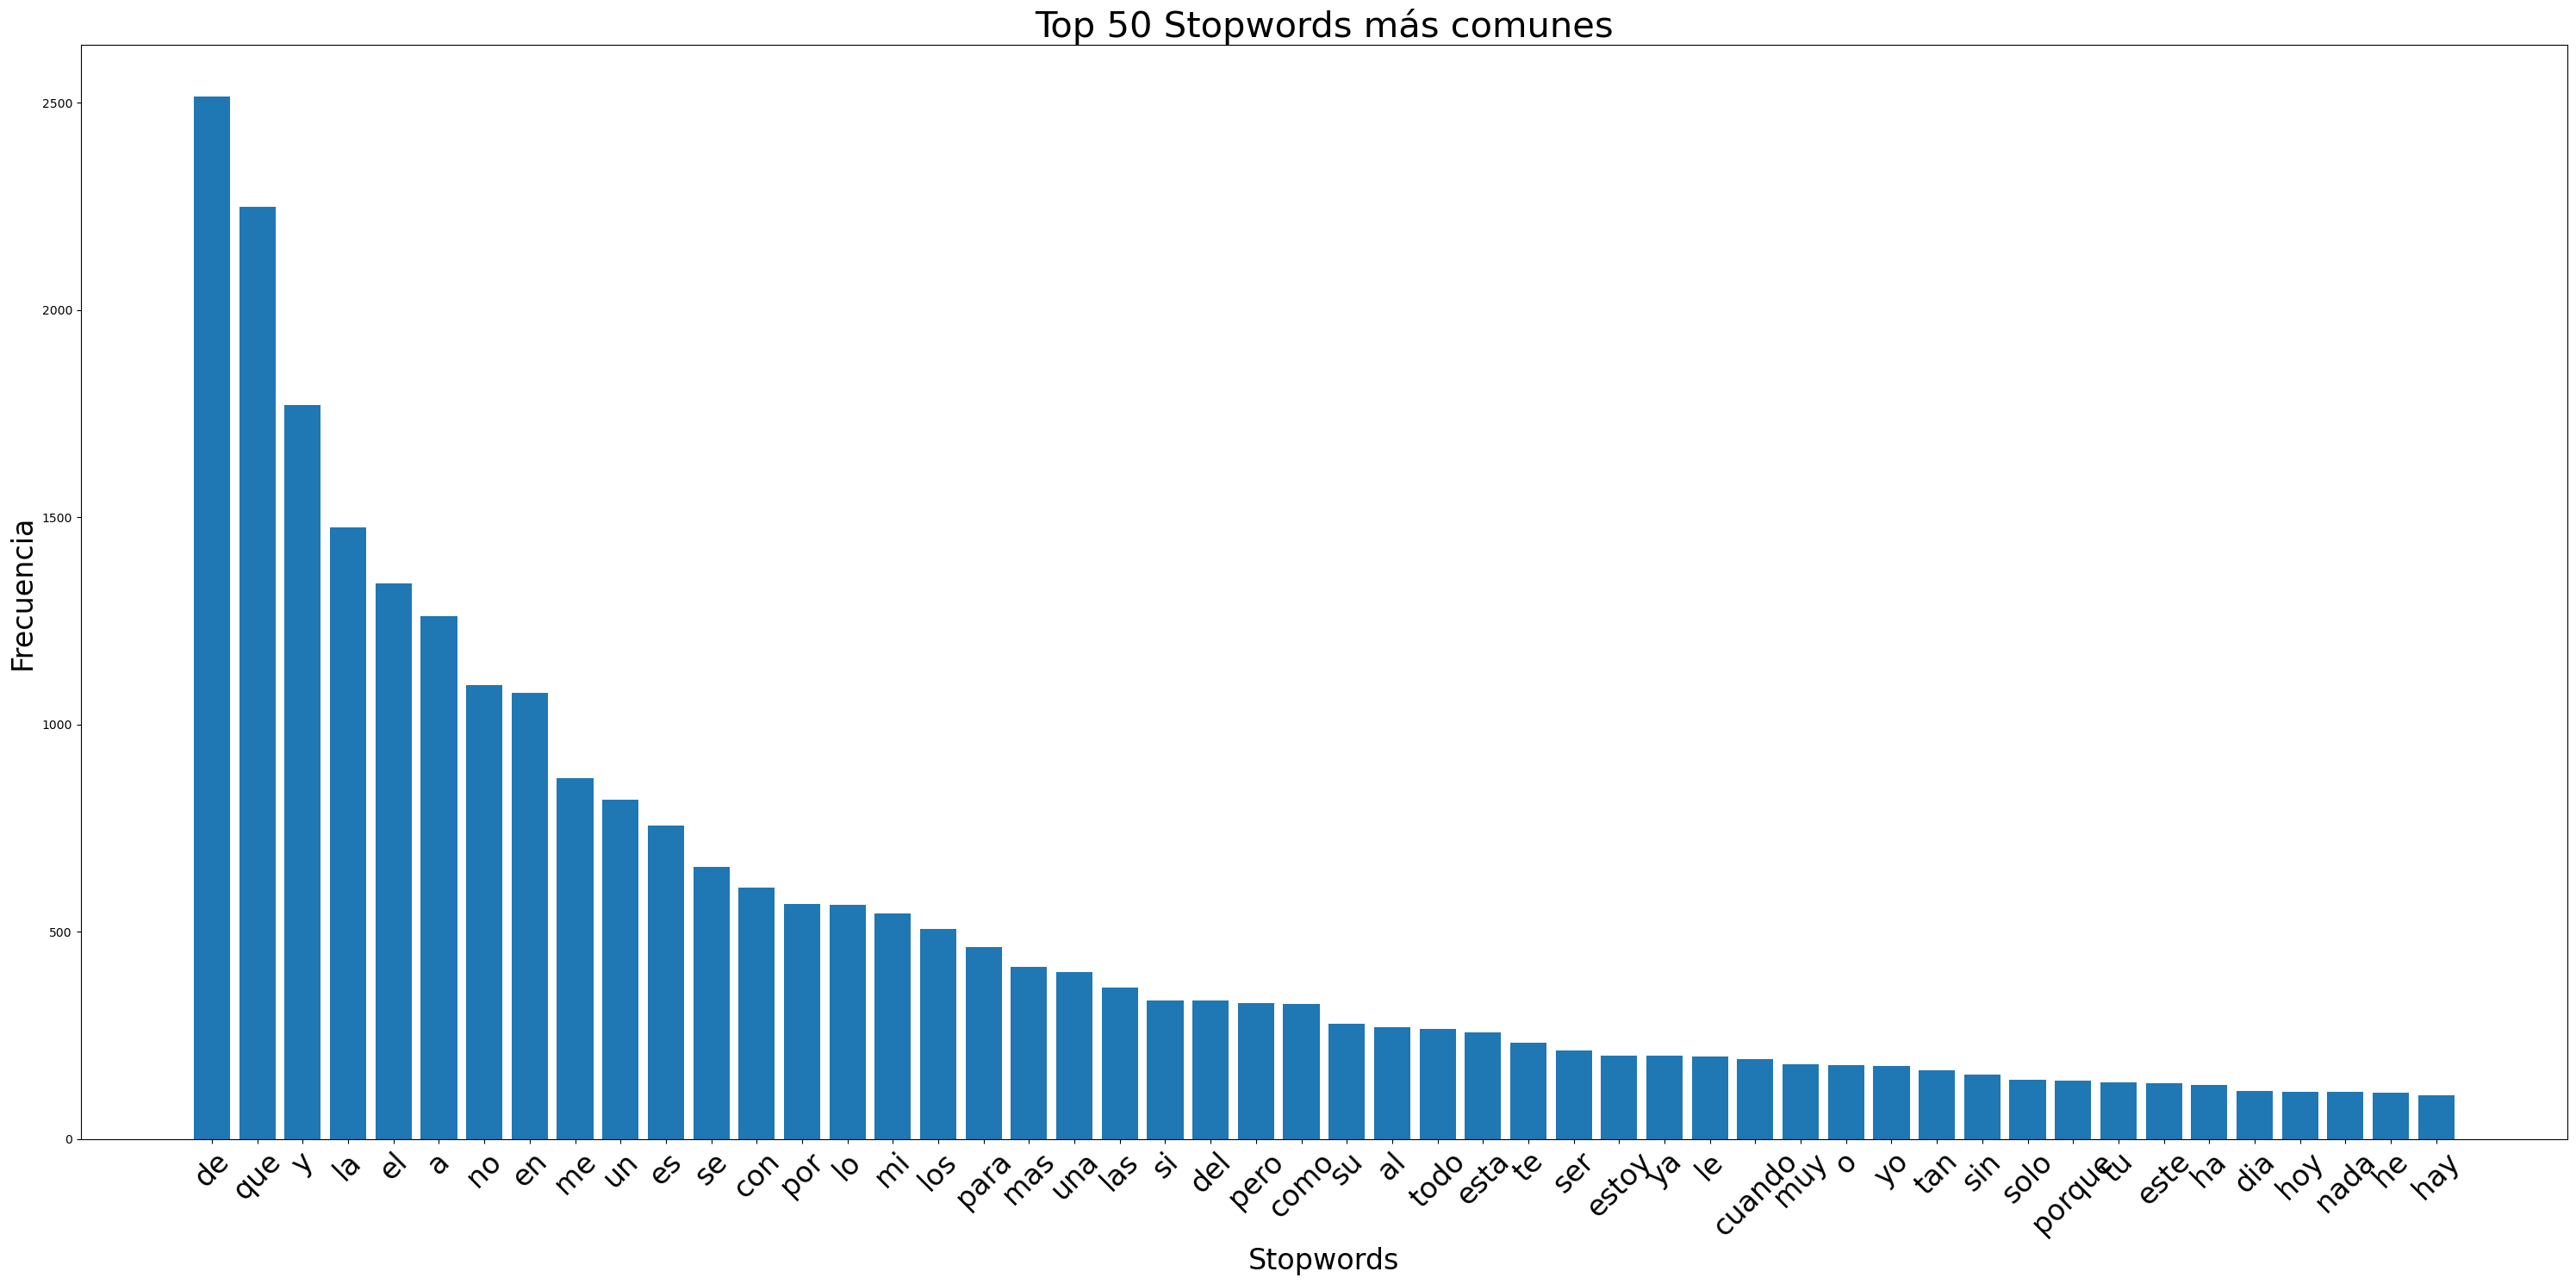

Hay un total de  388  palabras vacías distintas


In [4]:
nlp = spacy.load("es_core_news_sm") # Cargamos el modelo de lenguaje de spaCy para español
stopwords_freq = Counter() # Contador para almacenar la frecuencia de las palabras vacías

# eliminamos tildes, convertimos a minusculas y eliminamos caracteres especiales como ¡ ! , ( ) . ? ¿
df_procesado["text"] = df_procesado["text"].apply(limpieza_canonica.limpieza_canonica)

#extraemos las palabras vacias y contamos su frecuencia
contador = Counter()
for doc in nlp.pipe(df_procesado["text"].astype(str), batch_size=1000):
    contador.update(
        token.text.lower()
        for token in doc
        if token.is_stop 
    )

# Top 50 stopwords más frecuentes
top_50 = contador.most_common(50)
palabras = [w for w, _ in top_50]
frecuencias = [f for _, f in top_50]

plt.figure(figsize=(30, 15))
plt.bar(palabras, frecuencias)
plt.xticks(rotation=45, fontsize=24)
plt.xlabel("Stopwords", fontsize=24)
plt.ylabel("Frecuencia", fontsize=24)
plt.title("Top 50 Stopwords más comunes", fontsize=30)
plt.tight_layout()
plt.show()

print("Hay un total de ", len(contador), " palabras vacías distintas")

En circunstancias normales, la mayoría de estas palabras vacías podrían ser extraidas de las cadenas de texto en nuestro *corpus*, sin embargo, al estar realizando un análisis de sentimientos, palabras como *no*, *muy*, *tan* o *nada* no deben ser eliminadas, ya que estas, pueden aportar información crucial a la hora de realizar la clasificación de la `polarización`. De forma que, mantendremos las palabras no vacías y las palabras vacías que pueden aportar información relevante.

Específicamente, no se eliminaran las palabras vacías que aporten significado de negación (*no*, *ni*, *sin*...) ni conectores de contraste (*pero*, *aunque*, *tampoco*...). Tampoco se eliminarán emoticonos, ya que estos aportan una gran cantidada de información emocional.

In [5]:
palabras_vacias_relevantes = ["no", "ni", "nunca", "nadie", "nada", "ninguna", "ninguno", "tampoco", "sin", "sino",
                              "tan", "muy", "pero", "aunque", "embargo", "mientras"]

def filtrar_lemas(texto):
    doc = nlp(str(texto))
    tokens = []
    
    for token in doc:
        # Caso 1: emoticono o símbolo no alfabético pero no espacio
        if not token.is_alpha and not token.is_space:
            tokens.append(token.text)
            continue
        
        # Caso 2: palabra normal
        if (
            not token.is_stop
            or token.lemma_.lower() in palabras_vacias_relevantes
        ):
            tokens.append(token.lemma_.lower())
    return " ".join(tokens)

df_procesado_limpio = df_procesado["text"].apply(filtrar_lemas).to_frame(name="text")
display(df_procesado_limpio.sample(10, random_state=seed))

,text
1179,extraño figura casa atento resolvia ayudar mama
1204,ni tocar independizar él rapido
2576,jxc periodista defender justificamdo robo ataq...
422,comentario agrio hatir costco llegar conclusio...
695,no extrañar haber alejar amistad definitivamen...
194,pero pq sigo sintiendomir infeliz jamas estuvi...
296,gordo tipo asquerosamente facho odio corazon o...
1554,pena oklahoma reviveír condecorós derrota 20
1210,hora ver él espalda jusjsksjs flexible verselo...
173,regalar rosa bonito 💕 bonito sonrojado 💕


## ****3. Vectorización del corpus****

En esta fase, transformaremos el texto preprocesado en una representación numérica adecuada para el entrenamiento de modelos de clasificación. Para ello, se emplean dos enfoques clásicos en minería de textos:

**`Bag of Words`** (BoW) y **`TF-IDF`** (Term Frequency – Inverse Document Frequency).

Se ha limitado la dimensionalidad del espacio vectorial mediante los parámetros `min_df`, `max_df` y `max_features`, con el objetivo de:

- Reducir ruido léxico.
- Evitar términos extremadamente raros.
- Controlar la dimensionalidad del modelo para mejorar la generalización.

### **3.0. Separación Train-Test**
Para evitar el sobreajuste del modelo, antes de realizar la vectorización, debemos separar nuestro conjunto de datos en subconjunto de entrenamiento y de prueba para evitar ***fuga de datos***. En adición, realizaremos dos separaciones diferentes para comprobar las diferencias en el proceso de modelado entre realizar la estratificación de los datos o no.

In [6]:
X_text = df_procesado_limpio["text"]
y = df_procesado["polarity"]

X_train_text_estratificado, X_test_text_estratificado, y_train_estratificado, y_test_estratificado = train_test_split(
    X_text, y, test_size=0.2, random_state=seed, stratify=y
)

X_train_no_estratificado, X_test_no_estratificado, y_train_no_estratificado, y_test_no_estratificado = train_test_split(
    X_text, y, test_size=0.2, random_state=seed
)

print("Train (estratificado):", X_train_text_estratificado.shape, "Test:", X_test_text_estratificado.shape)
print("Train (no estratificado):", X_train_no_estratificado.shape, "Test:", X_test_no_estratificado.shape)

Train (estratificado): (2072,) Test: (518,)
Train (no estratificado): (2072,) Test: (518,)


### **3.1. Bag Of Words**

El modelo **`Bag of Words`** representa cada documento como un vector de frecuencias absolutas de términos.

Se ha configurado el vectorizador para:

- Excluir términos con frecuencia documental inferior a un umbral mínimo (min_df) a un 0.2% del conjunto de datos (5 documentos)
- Limitar el número máximo de características (max_features) a 1000 (61% del total de documentos)
- Incluir unigramas y, en su caso, bigramas.

#### **3.1.1. BoW estratificado**
Primero, crearemos la bolsa de palabras para el conjunto de entrenamiento que hemos estratificado...

In [7]:
def vectorizer_bow_fit_transform(
    X_train_text, X_test_text,
    min_df=0.002, max_features=1000, ngram_range=(1, 2)
):
    cv = CountVectorizer(min_df=min_df, max_features=max_features, ngram_range=ngram_range)

    X_train = cv.fit_transform(X_train_text)   # FIT solo en train
    X_test  = cv.transform(X_test_text)        # TRANSFORM en test

    feature_names = cv.get_feature_names_out()

    X_train_df = pd.DataFrame(X_train.toarray(), columns=feature_names, index=X_train_text.index)
    X_test_df  = pd.DataFrame(X_test.toarray(),  columns=feature_names, index=X_test_text.index)

    return cv, X_train_df, X_test_df

In [8]:
cv_estr, X_train_bow_estr, X_test_bow_estr = vectorizer_bow_fit_transform(
    X_train_text_estratificado, X_test_text_estratificado
)

# 1) DTM (muestra train)
display(X_train_bow_estr.sample(10, random_state=seed))

# 2) Tamaño final
print("Dimensión DTM BoW (train estratificado):", X_train_bow_estr.shape)
print("Dimensión DTM BoW (test  estratificado):", X_test_bow_estr.shape)

# 3) Top 20 términos más frecuentes (solo train)
top20_bow_estr = (
    X_train_bow_estr.sum(axis=0)
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
top20_bow_estr.columns = ["termino", "frecuencia"]

print("\nTop 20 términos más frecuentes (BoW) en TRAIN estratificado:")
display(top20_bow_estr)

,10,100,12,13,14,15,16,17,20,2023,...,volvi,voz,wey,xd,xq,yo,youtube,zona,él,él no
2180,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2555,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
711,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1857,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
1079,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1876,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
433,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,0
1280,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
75,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Dimensión DTM BoW (train estratificado): (2072, 1000)
Dimensión DTM BoW (test  estratificado): (518, 1000)

Top 20 términos más frecuentes (BoW) en TRAIN estratificado:


,termino,frecuencia
0,no,872
1,pero,263
2,él,221
3,sentir,127
4,sin,121
5,año,110
6,vida,107
7,ver,106
8,yo,103
9,querer,102


#### 3.1.2 BoW No estratificado
A continuación, repetimos el punto anterior pero empleando el conjunto de entrenamiento no estratificado


In [9]:
cv_noestr, X_train_bow_noestr, X_test_bow_noestr = vectorizer_bow_fit_transform(
    X_train_no_estratificado, X_test_no_estratificado
)

# 1) DTM (muestra train)
display(X_train_bow_noestr.sample(10, random_state=seed))

# 2) Tamaño final
print("Dimensión DTM BoW (train no estratificado):", X_train_bow_noestr.shape)
print("Dimensión DTM BoW (test  no estratificado):", X_test_bow_noestr.shape)

# 3) Top 20 términos más frecuentes (solo train)
top20_bow_noestr = (
    X_train_bow_noestr.sum(axis=0)
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
top20_bow_noestr.columns = ["termino", "frecuencia"]

print("\nTop 20 términos más frecuentes (BoW) en TRAIN no estratificado:")
display(top20_bow_noestr)

,00,10,100,12,14,15,16,17,20,2023,...,volver,volvi,voz,xd,xq,yo,youtube,zona,él,él no
125,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
107,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1494,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2100,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1446,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1263,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
705,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
213,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2499,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,0


Dimensión DTM BoW (train no estratificado): (2072, 1000)
Dimensión DTM BoW (test  no estratificado): (518, 1000)

Top 20 términos más frecuentes (BoW) en TRAIN no estratificado:


,termino,frecuencia
0,no,892
1,pero,254
2,él,203
3,sentir,131
4,sin,127
5,vida,116
6,ver,109
7,querer,106
8,año,105
9,yo,99


### **3.2. TF-IDF**

El modelo TF-IDF pondera cada término en función de:

- Su frecuencia en el documento.
- Su rareza en el conjunto total de documentos.

Este enfoque reduce el peso de términos muy comunes y aumenta la relevancia de términos discriminativos. Se ha configurado con los mismos parámetros que BoW.

#### **3.2.1. TF-IDF estratificado**

In [10]:
def vectorizer_tfidf_fit_transform(
    X_train_text, X_test_text,
    min_df=0.002, max_features=1000, ngram_range=(1, 2)
):
    tv = TfidfVectorizer(min_df=min_df, max_features=max_features, ngram_range=ngram_range)

    X_train = tv.fit_transform(X_train_text)   # FIT solo en train
    X_test  = tv.transform(X_test_text)        # TRANSFORM en test

    feature_names = tv.get_feature_names_out()

    X_train_df = pd.DataFrame(X_train.toarray(), columns=feature_names, index=X_train_text.index)
    X_test_df  = pd.DataFrame(X_test.toarray(),  columns=feature_names, index=X_test_text.index)

    return tv, X_train_df, X_test_df

In [11]:
tv_estr, X_train_tfidf_estr, X_test_tfidf_estr = vectorizer_tfidf_fit_transform(
    X_train_text_estratificado, X_test_text_estratificado
)

# 1) DTM (muestra train)
display(X_train_tfidf_estr.sample(10, random_state=seed))

# 2) Tamaño final
print("Dimensión DTM TF-IDF (train estratificado):", X_train_tfidf_estr.shape)
print("Dimensión DTM TF-IDF (test  estratificado):", X_test_tfidf_estr.shape)

# 3) Top 20 términos con mayor peso medio (solo train)
top20_tfidf_estr = (
    X_train_tfidf_estr.mean(axis=0)
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
top20_tfidf_estr.columns = ["termino", "peso_medio_tfidf"]

print("\nTop 20 términos más relevantes (TF-IDF) en TRAIN estratificado:")
display(top20_tfidf_estr)

,10,100,12,13,14,15,16,17,20,2023,...,volvi,voz,wey,xd,xq,yo,youtube,zona,él,él no
2180,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
2555,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
498,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
711,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
1857,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.618724,0.0,0.0,0.000000,0.0
1079,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
1876,0.540193,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
433,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.419415,0.0
1280,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
75,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0


Dimensión DTM TF-IDF (train estratificado): (2072, 1000)
Dimensión DTM TF-IDF (test  estratificado): (518, 1000)

Top 20 términos más relevantes (TF-IDF) en TRAIN estratificado:


,termino,peso_medio_tfidf
0,no,0.058787
1,pero,0.026503
2,él,0.021179
3,sentir,0.016377
4,querer,0.014413
5,sin,0.014297
6,año,0.013839
7,ver,0.013818
8,yo,0.013316
9,vida,0.012624


#### **3.2.2. TF-IDF no estratificado**
Repetiremos el punto anterior, pero utilizando el conjunto de datos de entrenamiento no estratificado

In [12]:
tv_noestr, X_train_tfidf_noestr, X_test_tfidf_noestr = vectorizer_tfidf_fit_transform(
    X_train_no_estratificado, X_test_no_estratificado,
)

# 1) DTM (muestra train)
display(X_train_tfidf_noestr.sample(10, random_state=seed))

# 2) Tamaño final
print("Dimensión DTM TF-IDF (train no estratificado):", X_train_tfidf_noestr.shape)
print("Dimensión DTM TF-IDF (test  no estratificado):", X_test_tfidf_noestr.shape)

# 3) Top 20 términos con mayor peso medio (solo train)
top20_tfidf_noestr = (
    X_train_tfidf_noestr.mean(axis=0)
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
top20_tfidf_noestr.columns = ["termino", "peso_medio_tfidf"]

print("\nTop 20 términos más relevantes (TF-IDF) en TRAIN no estratificado:")
display(top20_tfidf_noestr)

,00,10,100,12,14,15,16,17,20,2023,...,volver,volvi,voz,xd,xq,yo,youtube,zona,él,él no
125,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
107,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
1494,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
2100,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.152880,0.0
1446,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
1263,0.0,0.365471,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
705,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.190715,0.0,0.0,0.000000,0.0
213,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.170614,0.0
1366,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
2499,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.329816,0.0


Dimensión DTM TF-IDF (train no estratificado): (2072, 1000)
Dimensión DTM TF-IDF (test  no estratificado): (518, 1000)

Top 20 términos más relevantes (TF-IDF) en TRAIN no estratificado:


,termino,peso_medio_tfidf
0,no,0.059413
1,pero,0.025982
2,él,0.020057
3,sentir,0.016613
4,sin,0.014866
5,ver,0.014577
6,querer,0.014222
7,año,0.013739
8,vida,0.013725
9,yo,0.012455


## ****4. Entrenamiento y evaluación de modelos mediante esquema de retención (80/20)****

Preparados todos los datos a utilizar, procedemos a la creación de la estructura de los modelos que los procesarán y, a su entrenamiento con el esquema de retención creado anteriormente en la subsección `3.0. Separación Train-Test`. Para esta práctica, se crearán tres modelos que se entrenarán para ambas versiones de DTM obtenida anteriormente. Es decir, tanto para BoW como TF-IDF. Y, se tratarán de `Naive Bayes`, `Regresión Logística` y `Random Forest`. Pero antes, prepararemos una función que mida todas las métricas requeridas...

In [13]:
# Función para evaluación de los modelos

def evaluacion_modelos(y_pred, y_test):

    # Cálculos
    matriz_confusion = confusion_matrix(y_test, y_pred)
    reporte = classification_report(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred)

    # Layout
    fig = plt.figure(figsize=(12,8))
    gs = gridspec.GridSpec(2, 2, height_ratios=[3, 1.5], hspace=0.5)

    # =========================
    # MATRIZ DE CONFUSIÓN
    # =========================
    ax0 = fig.add_subplot(gs[0, 0])
    sns.heatmap(
        matriz_confusion,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Pred. Negativo", "Pred. Positivo"],
        yticklabels=["Real Negativo", "Real Positivo"],
        ax=ax0
    )
    ax0.set_title("Matriz de Confusión")
    ax0.set_xlabel("Valores Predichos")
    ax0.set_ylabel("Valores Reales")

    # =========================
    # CURVA ROC
    # =========================
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
    ax1.plot([0,1], [0,1], linestyle="--")
    ax1.set_title("Curva ROC")
    ax1.set_xlabel("Tasa de Falsos Positivos (FPR)")
    ax1.set_ylabel("Tasa de Verdaderos Positivos (TPR)")
    ax1.legend()

    # =========================
    # REPORTE DE CLASIFICACIÓN
    # =========================
    ax2 = fig.add_subplot(gs[1, :])
    ax2.axis("off")
    ax2.text(
        0,
        1,
        "Reporte de Clasificación\n\n" + reporte,
        fontsize=11,
        verticalalignment="top",
        family="monospace"
    )

    plt.tight_layout()
    plt.show()

### **4.1 Naive Bayes**

El primer modelo que utilizaremos se trata de Naive Bayes. Uno de los modelos del que vamos a hacer uso más simples el cual, no posee hiperparámetros a destacar. Para cada uno de los modelos, se hará una función en la que realizaremos el entrenamiento respectivo y, obtendremos la predicción.

NAIVE BAYES - BoW ESTRATIFICADO


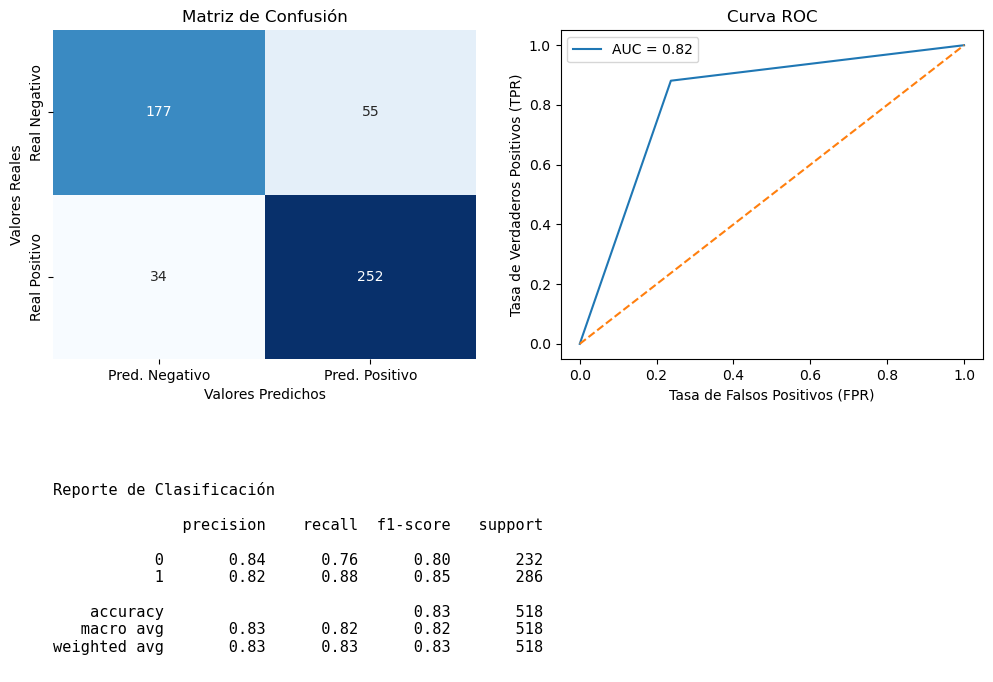




NAIVE BAYES - BoW NO ESTRATIFICADO


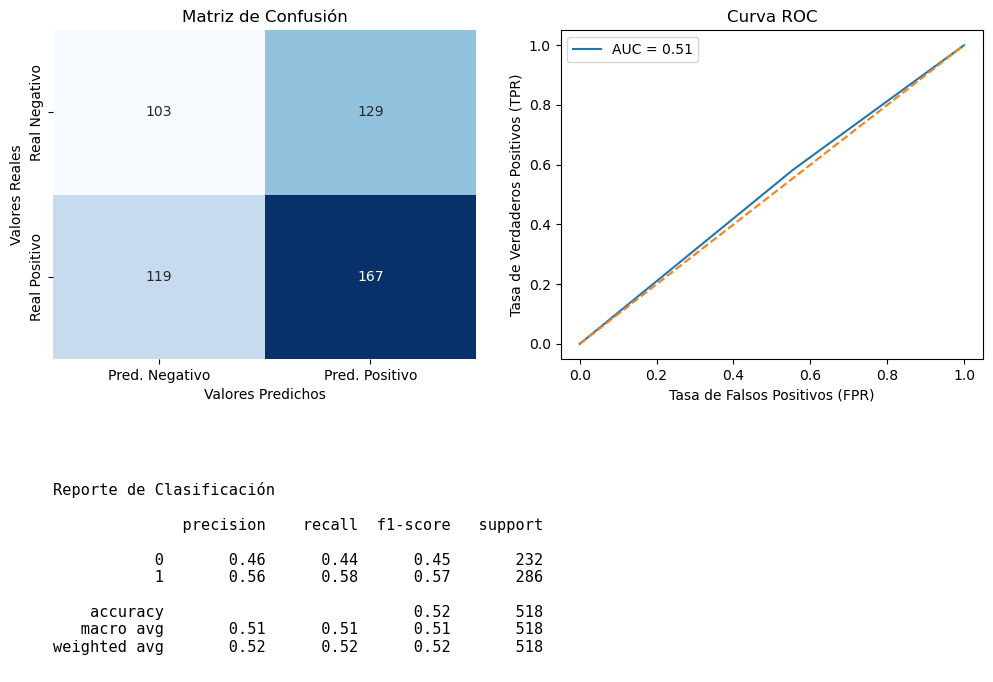

NAIVE BAYES - TF-IDF ESTRATIFICADO


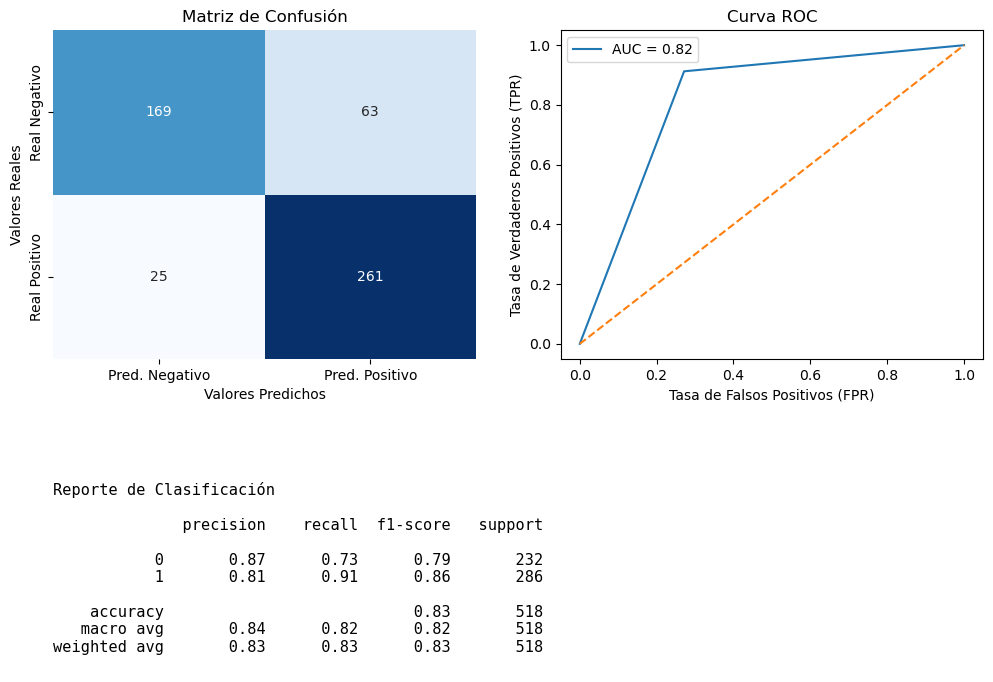




NAIVE BAYES - TF-IDF NO ESTRATIFICADO


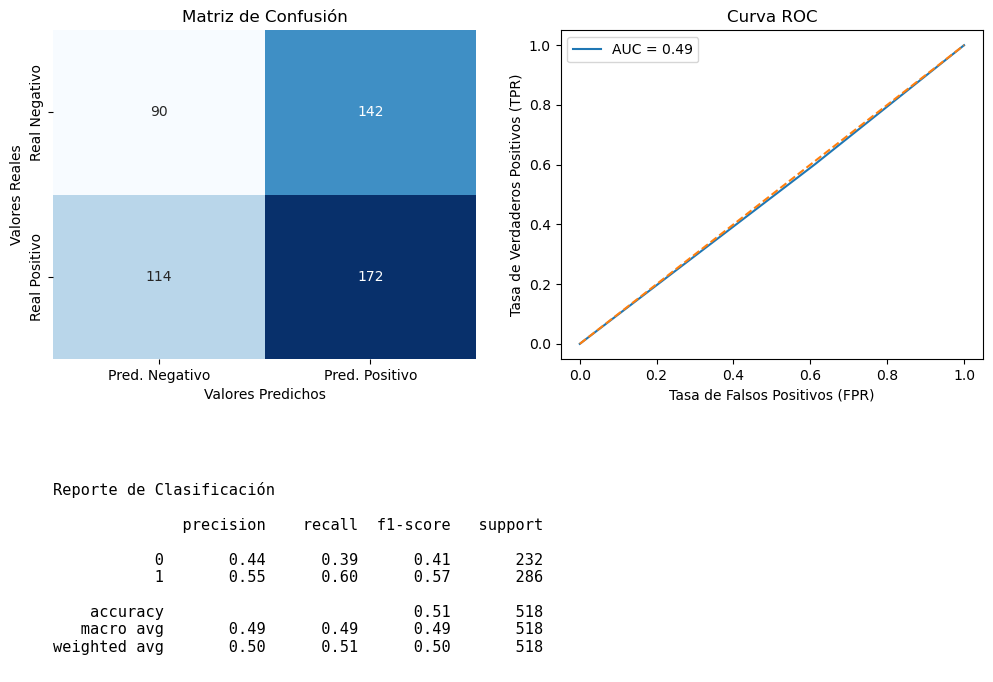

In [14]:
def naive_bayes(X_train, y_train, X_test):

    modelo = MultinomialNB() # Creación del modelo

    modelo.fit(X_train, y_train) # Entrenamiento

    y_pred = modelo.predict(X_test) # Evaluación de test

    return y_pred

# Bag Of Words
# 1. BoW Estratificado
print("NAIVE BAYES - BoW ESTRATIFICADO")
y_pred = naive_bayes(X_train_bow_estr, y_train_estratificado, X_test_bow_estr)
evaluacion_modelos(y_pred, y_test_estratificado)
print("\n\n")
# 2. BoW No Estratificado
print("NAIVE BAYES - BoW NO ESTRATIFICADO")
y_pred = naive_bayes(X_train_bow_noestr, y_train_no_estratificado, X_test_bow_noestr)
evaluacion_modelos(y_pred, y_test_estratificado)

# TF-IDF
# 1. TF-IDF Estratificado
print("NAIVE BAYES - TF-IDF ESTRATIFICADO")
y_pred = naive_bayes(X_train_tfidf_estr, y_train_estratificado, X_test_tfidf_estr)
evaluacion_modelos(y_pred, y_test_estratificado)
print("\n\n")
# 2. TF-IDF No Estratificado
print("NAIVE BAYES - TF-IDF NO ESTRATIFICADO")
y_pred = naive_bayes(X_train_tfidf_noestr, y_train_no_estratificado, X_test_tfidf_noestr)
evaluacion_modelos(y_pred, y_test_estratificado)

### **4.2. Regresión Logística**

Para el segundo modelo, tenemos la regresión logística. La estructura de la función será igual que para `Naive Bayes` pero, en este caso, haremos uso del siguiente hiperparámetro:

- **`Solver`**: hiperparámetro que nos permite seleccionar el algoritmo a utilizar en la optimización del problema en cuestión. Por defecto, está el algoritmo `lbfgs` pero, en nuestro caso, utilizaremos `liblinear` al responder de manera más eficiente en conjuntos de datos medianos y pequeños de variable clase binaria.

REGRESIÓN LOGÍSTICA - BoW ESTRATIFICADO


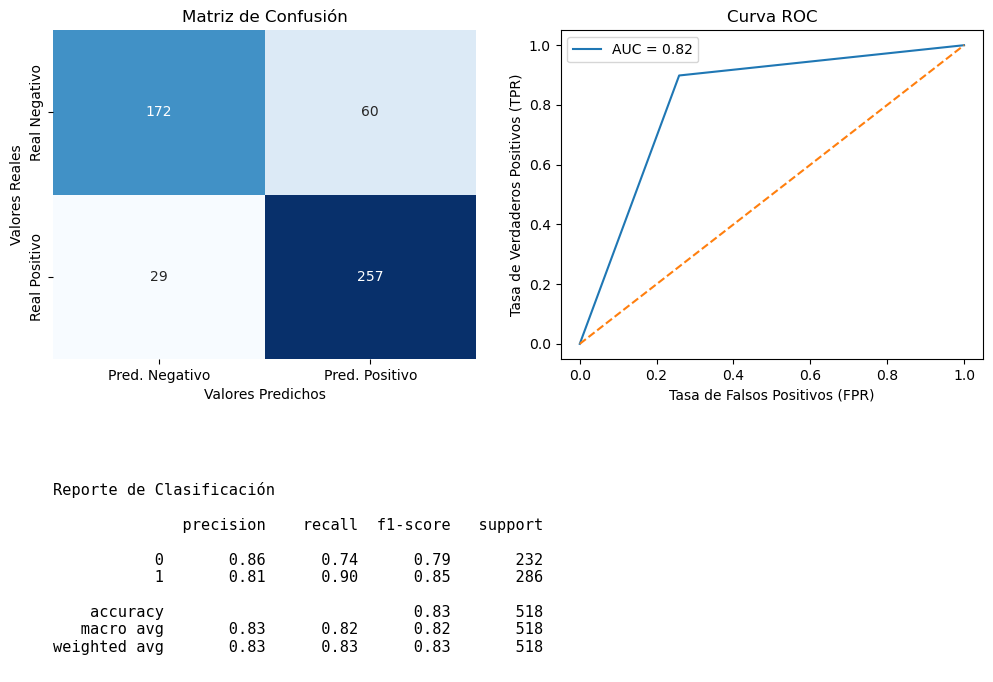




REGRESIÓN LOGÍSTICA - BoW NO ESTRATIFICADO


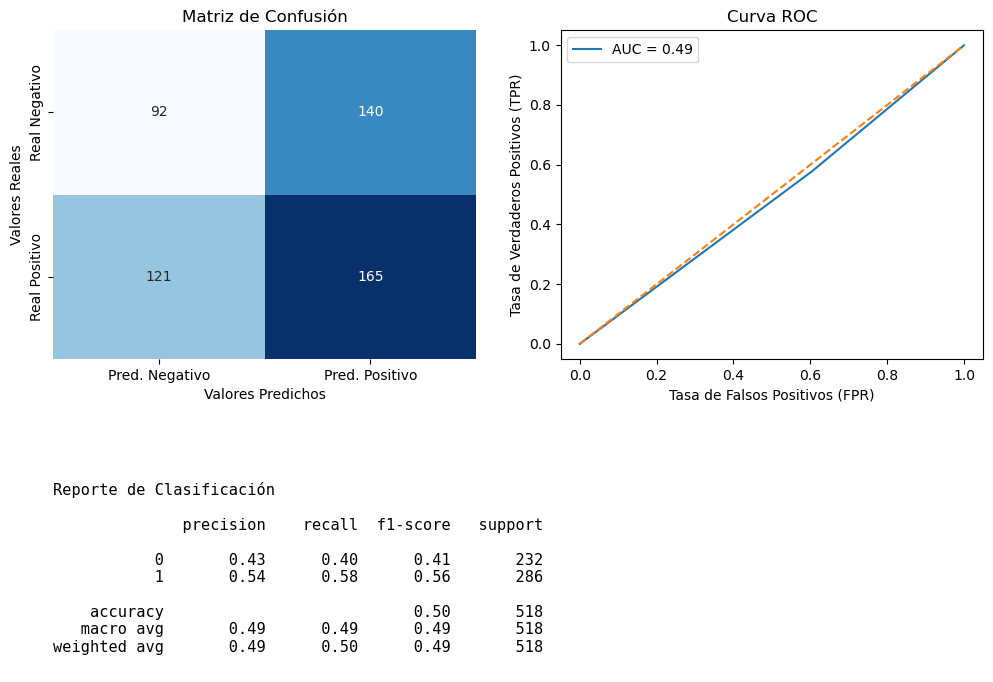

REGRESIÓN LOGÍSTICA - TF-IDF ESTRATIFICADO


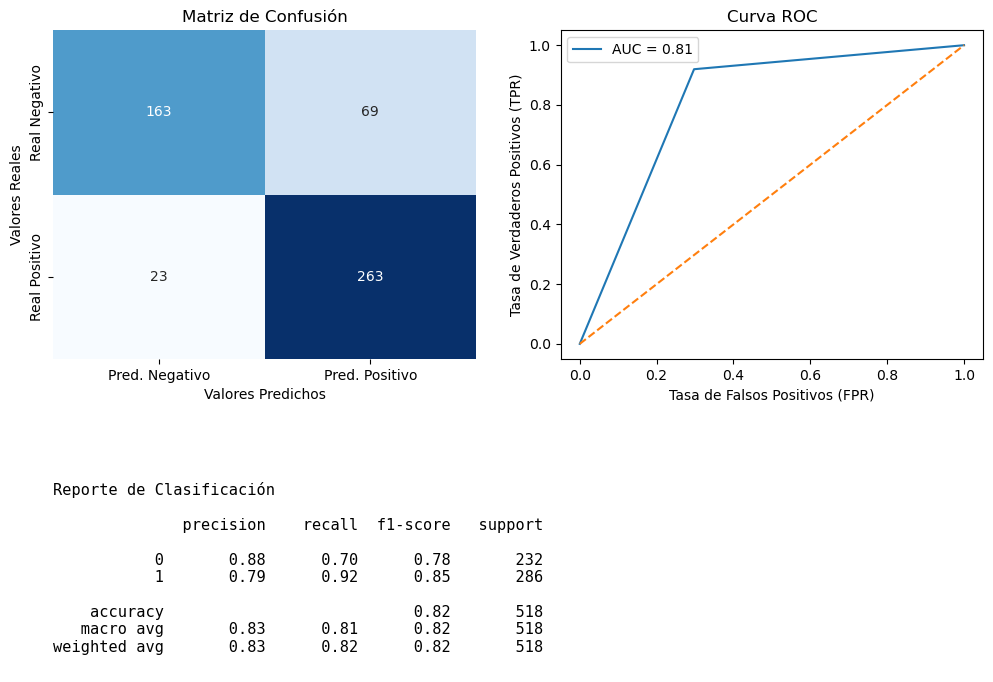




REGRESIÓN LOGÍSTICA - TF-IDF NO ESTRATIFICADO


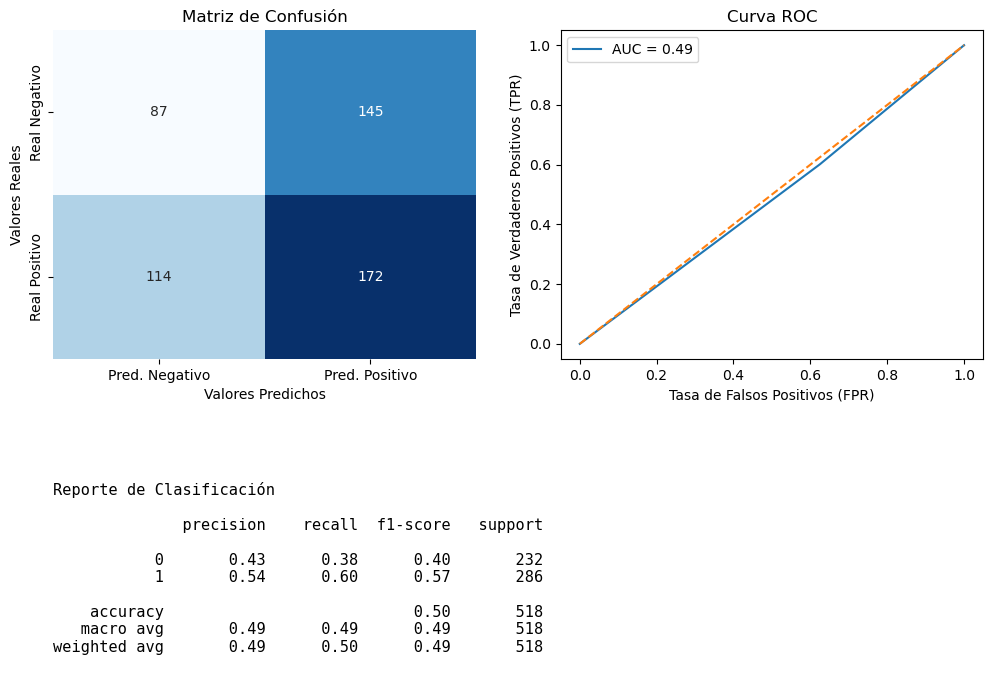

In [15]:
def regresion_log(X_train, y_train, X_test):

    modelo = LogisticRegression(solver = 'liblinear', random_state=42) # Creación del modelo

    modelo.fit(X_train, y_train) # Entrenamiento

    y_pred = modelo.predict(X_test) # Evaluación de test

    return y_pred

# Bag Of Words
# 1. BoW Estratificado
print("REGRESIÓN LOGÍSTICA - BoW ESTRATIFICADO")
y_pred = regresion_log(X_train_bow_estr, y_train_estratificado, X_test_bow_estr)
evaluacion_modelos(y_pred, y_test_estratificado)
print("\n\n")
# 2. BoW No Estratificado
print("REGRESIÓN LOGÍSTICA - BoW NO ESTRATIFICADO")
y_pred = regresion_log(X_train_bow_noestr, y_train_no_estratificado, X_test_bow_noestr)
evaluacion_modelos(y_pred, y_test_estratificado)

# TF-IDF
# 1. TF-IDF Estratificado
print("REGRESIÓN LOGÍSTICA - TF-IDF ESTRATIFICADO")
y_pred = regresion_log(X_train_tfidf_estr, y_train_estratificado, X_test_tfidf_estr)
evaluacion_modelos(y_pred, y_test_estratificado)
print("\n\n")
# 2. TF-IDF No Estratificado
print("REGRESIÓN LOGÍSTICA - TF-IDF NO ESTRATIFICADO")
y_pred = regresion_log(X_train_tfidf_noestr, y_train_no_estratificado, X_test_tfidf_noestr)
evaluacion_modelos(y_pred, y_test_estratificado)

### **4.3. Random Forest** 

Para terminar, haremos uso de un modelo ensemble. Siendo este, `Random Forest` el cual, se trata de un meta-clasificador que hace uso de una cantidad de clasificadores de árboles de decisión indicada por el programador. Debido a ello, los hiperparámetros que vamos a utilizar son:

- **`criterion`**: hiperparámetro que permite seleccionar la función que permite medir la calidad del umbral para las divisiones en los árboles. Para este problema haremos uso del criterio `entropy` que trabaja con la ganancia de información. Se trata de un criterio más lento de aplicar que el por defecto `gini` pero, al tratarse de un problema con una cantidad de datos no muy alta, se realiza en un tiempo aceptable.
- **`max_leaf_nodes`**: hiperparámetro que nos permitirá limitar el número de nodos hoja que puede realizar el ensemble por clasificador. En este caso, hemos introducido un límite de 300 nodos, permitiendo, que al tener un límite establecido, no realice un sobreajuste tan pronunciado.

RANDOM FOREST - BoW ESTRATIFICADO


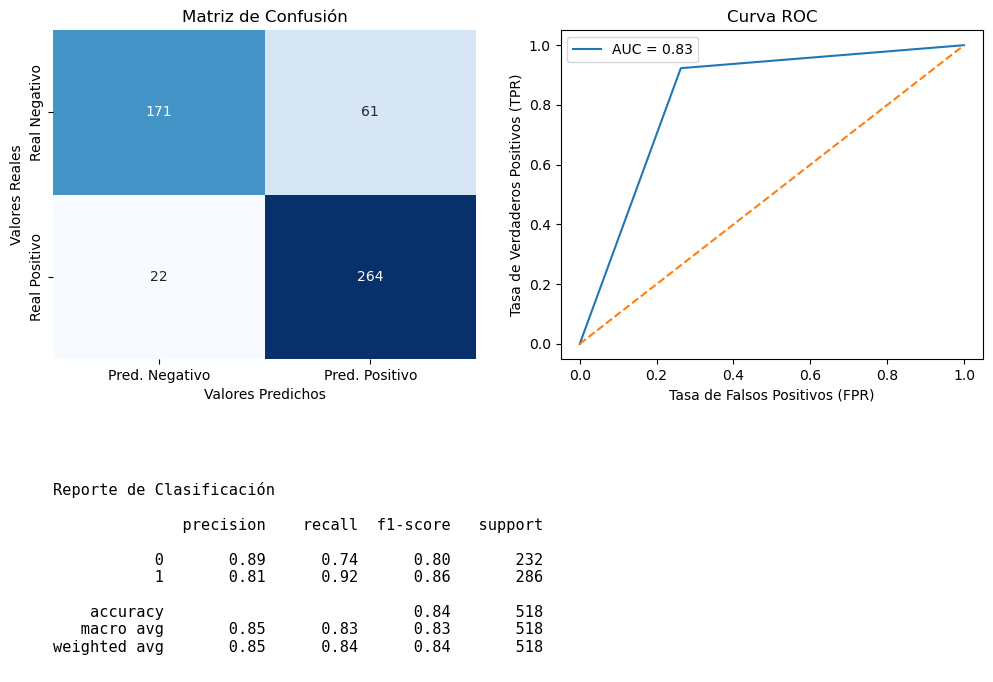




RANDOM FOREST - BoW NO ESTRATIFICADO


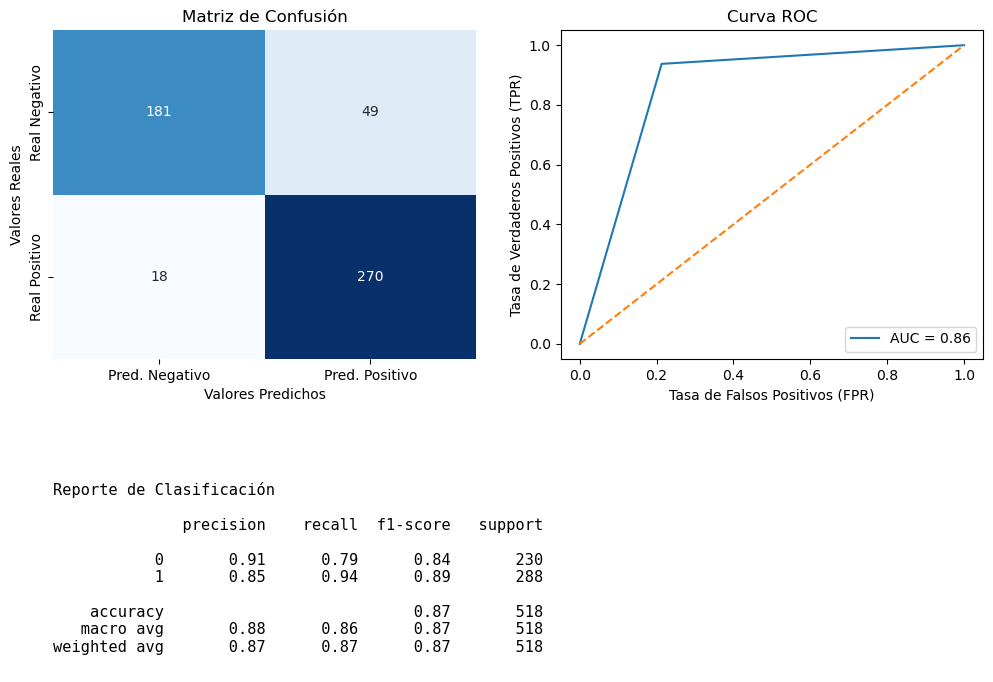

RANDOM FOREST - TF-IDF ESTRATIFICADO


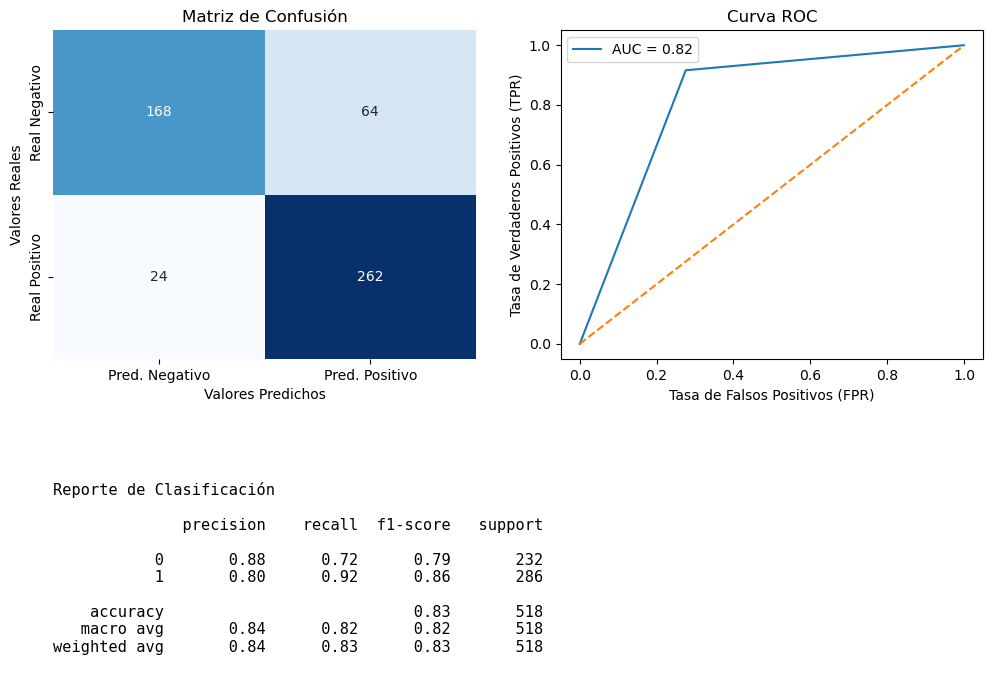




RANDOM FOREST - TF-IDF NO ESTRATIFICADO


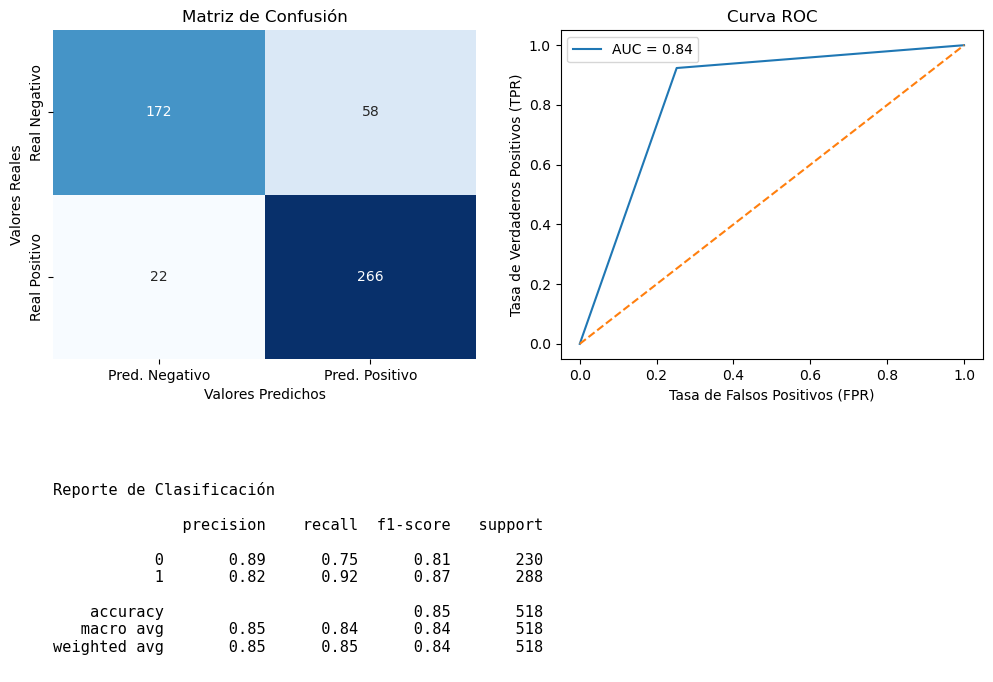

In [16]:
def random_forest(X_train, y_train, X_test):

    modelo = RandomForestClassifier(random_state=42, criterion='entropy', max_leaf_nodes=300) # Creación del modelo

    modelo.fit(X_train, y_train) # Entrenamiento

    y_pred = modelo.predict(X_test) # Evaluación de test

    return y_pred

# Bag Of Words
# 1. BoW Estratificado
print("RANDOM FOREST - BoW ESTRATIFICADO")
y_pred = random_forest(X_train_bow_estr, y_train_estratificado, X_test_bow_estr)
evaluacion_modelos(y_pred, y_test_estratificado)
print("\n\n")
# 2. BoW No Estratificado
print("RANDOM FOREST - BoW NO ESTRATIFICADO")
y_pred = random_forest(X_train_bow_noestr, y_train_no_estratificado, X_test_bow_noestr)
evaluacion_modelos(y_pred, y_test_no_estratificado)

# TF-IDF
# 1. TF-IDF Estratificado
print("RANDOM FOREST - TF-IDF ESTRATIFICADO")
y_pred = random_forest(X_train_tfidf_estr, y_train_estratificado, X_test_tfidf_estr)
evaluacion_modelos(y_pred, y_test_estratificado)
print("\n\n")
# 2. TF-IDF No Estratificado
print("RANDOM FOREST - TF-IDF NO ESTRATIFICADO")
y_pred = random_forest(X_train_tfidf_noestr, y_train_no_estratificado, X_test_tfidf_noestr)
evaluacion_modelos(y_pred, y_test_no_estratificado)

## ****5. Evaluación mediante validación cruzada****

Tras la realización de los modelos y, su evaluación a través de la técnica de retención (80/20), realizaremos el mismo análisis pero, esta vez, realizando la evaluación con `validación cruzada` (cross-validation) mediante `StratifiedKFold`.

In [17]:
# Definimos el objeto de validación cruzada estratificada con 10 folds, barajado y con semilla fija para reproducibilidad
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)

Una vez preparado el objeto de validación cruzada, realizamos la función que nos va a proporcionar todas las métricas pedidas (en este caso, acumuladas)...

VALIDACIÓN CRUZADA - NAIVE BAYES - BoW ESTRATIFICADO


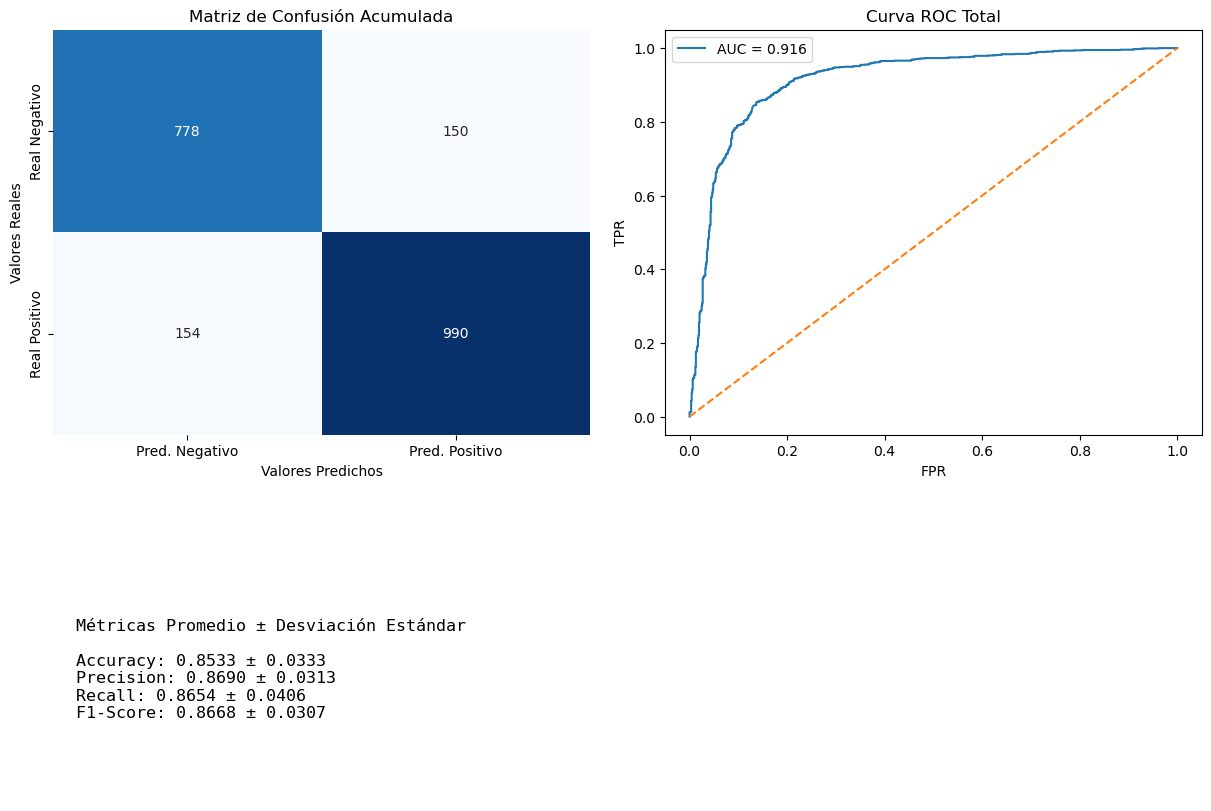




VALIDACIÓN CRUZADA - REGRESIÓN LOGÍSTICA - BoW ESTRATIFICADO


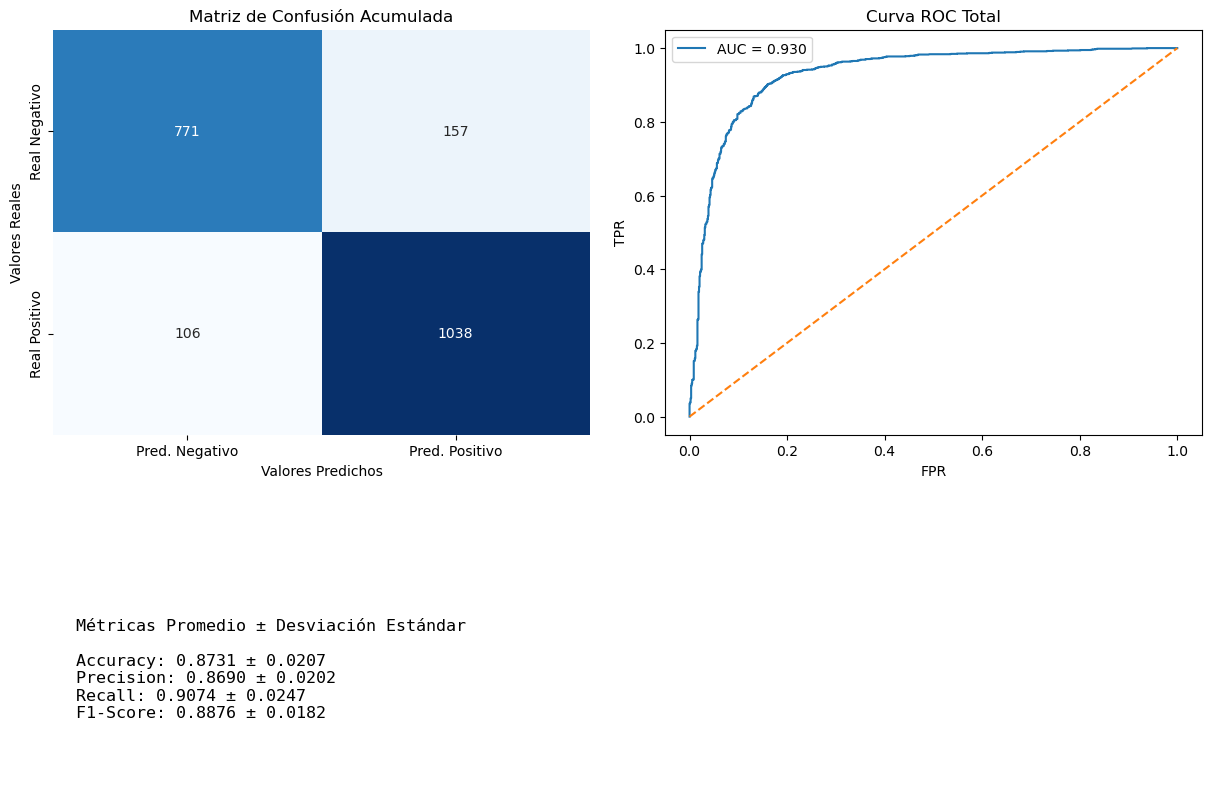




VALIDACIÓN CRUZADA - RANDOM FOREST - BoW ESTRATIFICADO


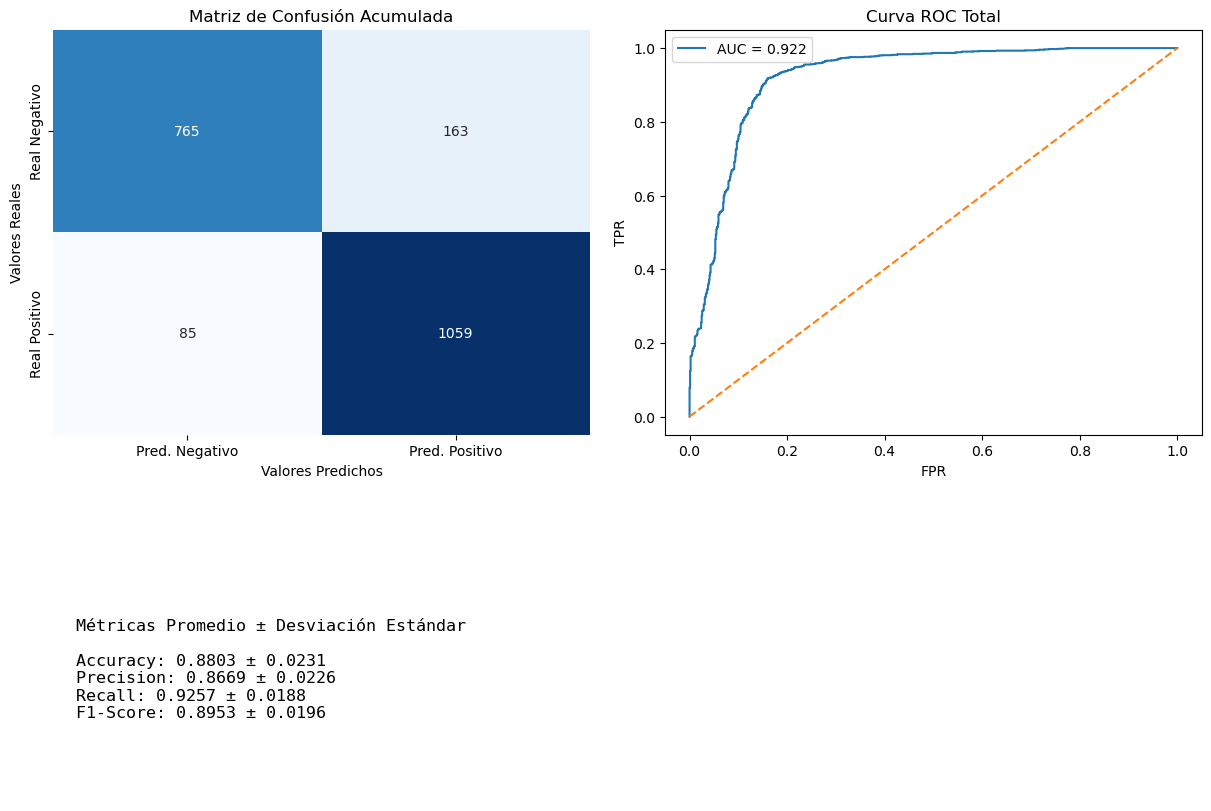




VALIDACIÓN CRUZADA - NAIVE BAYES - TF-IDF ESTRATIFICADO


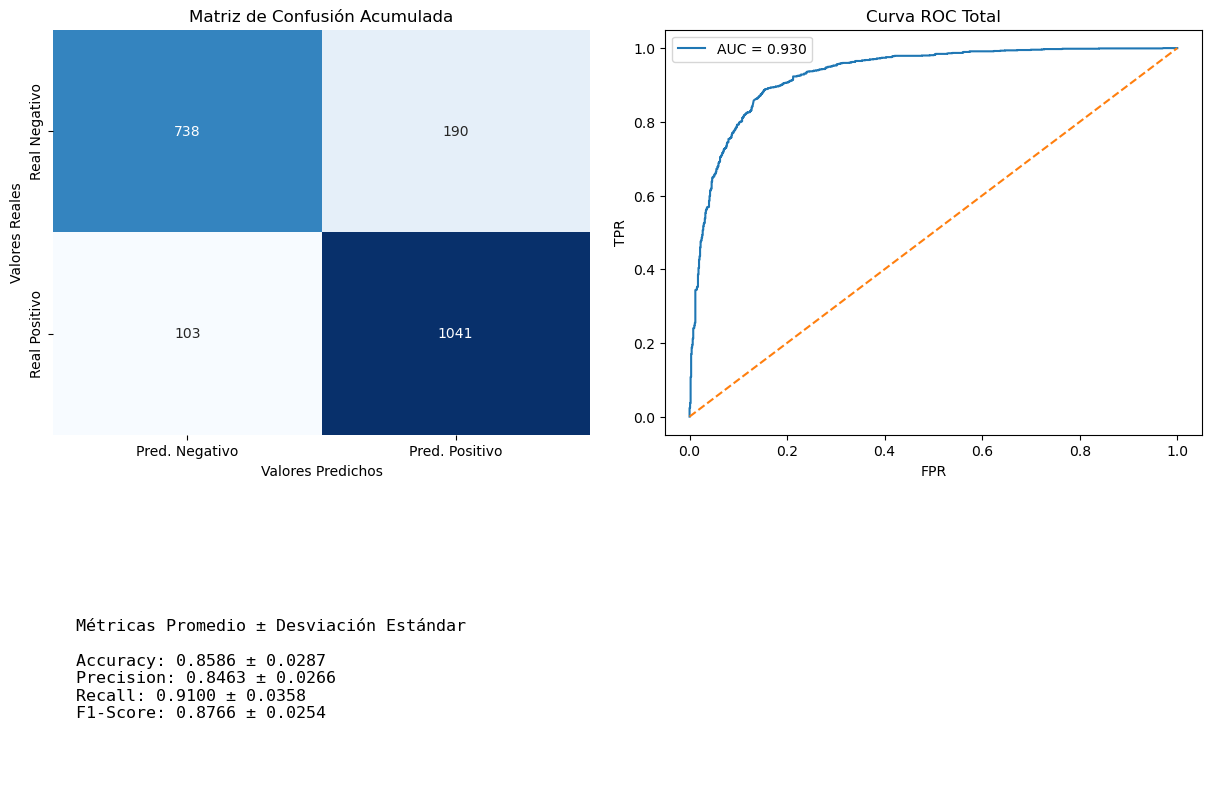




VALIDACIÓN CRUZADA - REGRESIÓN LOGÍSTICA - TF-IDF ESTRATIFICADO


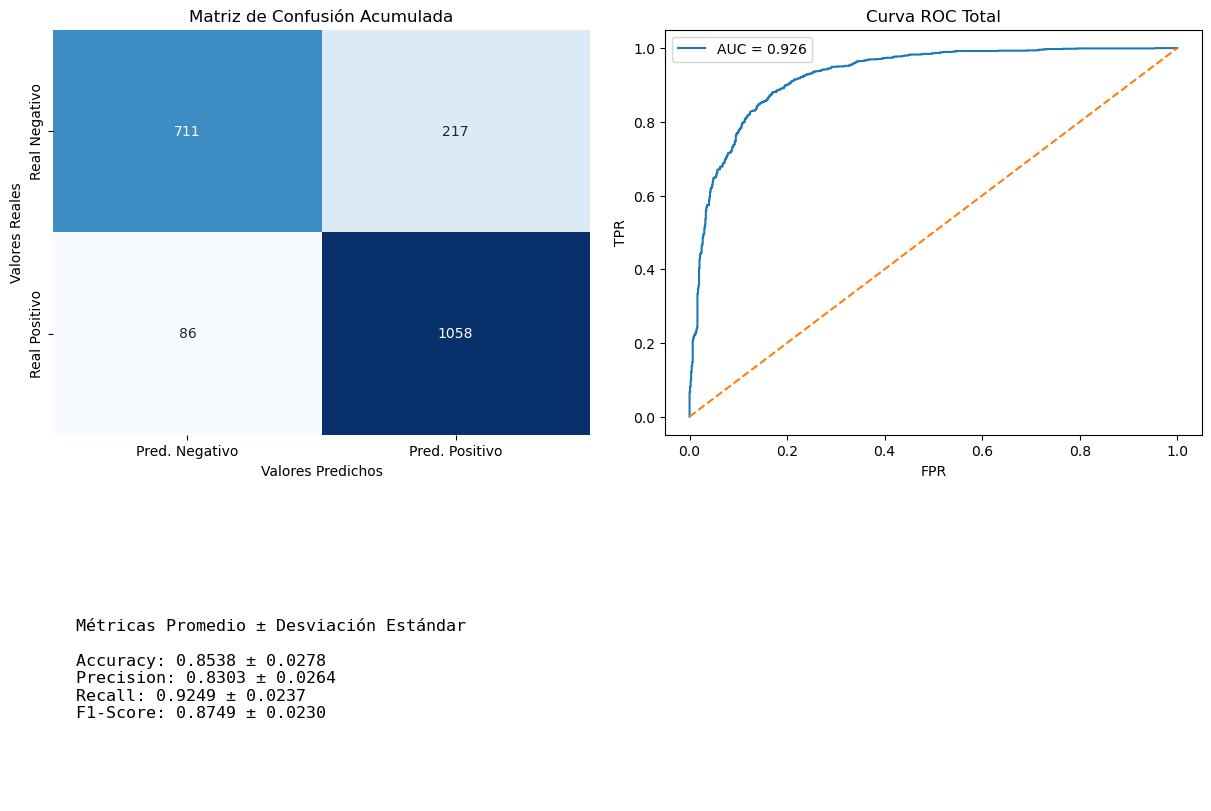




VALIDACIÓN CRUZADA - RANDOM FOREST - TF-IDF ESTRATIFICADO


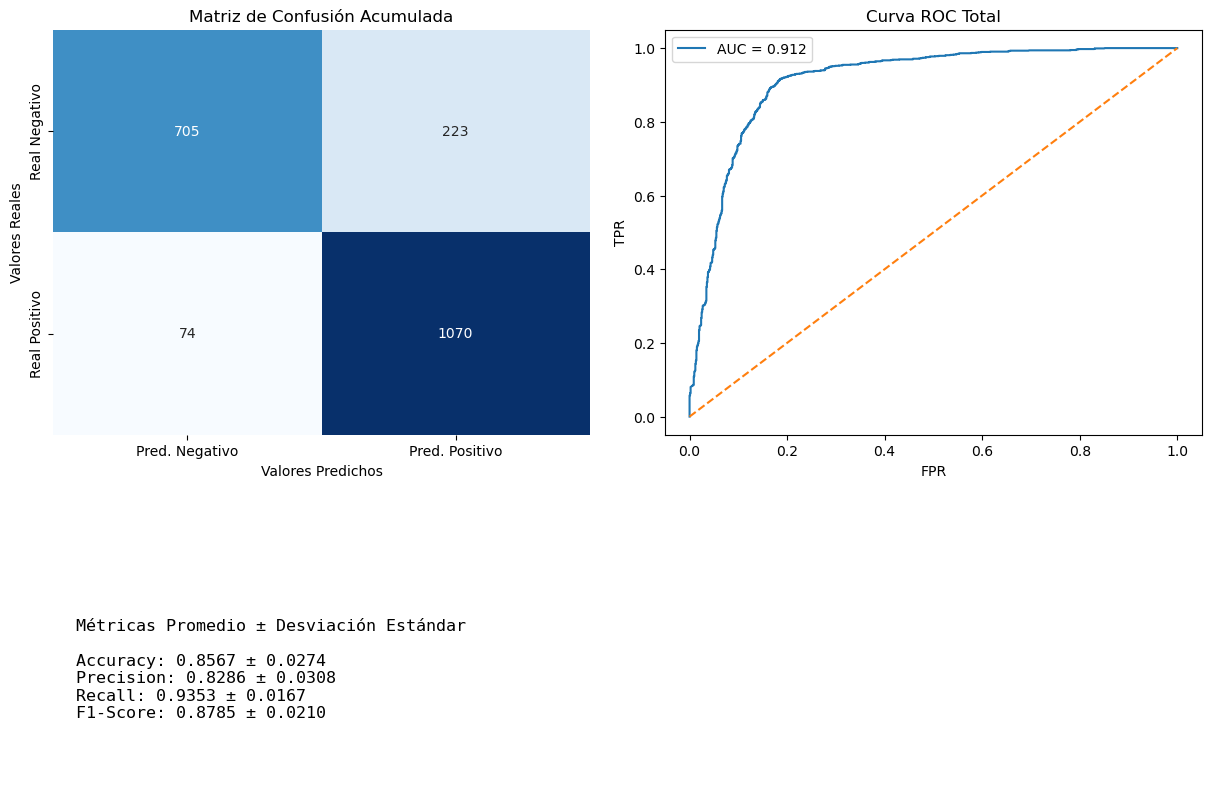

In [18]:
def validacion_cruzada(modelo, X, y, cv):

    matriz_confusion_total = np.zeros((2, 2), dtype=int)
    y_pred_total = []
    y_test_total = []
    accuracy_total = []
    precision_total = []
    recall_total = []
    f1_total = []

    for train_index, test_index in cv.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict_proba(X_test)[:, 1]

        y_pred_binaria = (y_pred > 0.5).astype(int)
        cm = confusion_matrix(y_test, y_pred_binaria)
        matriz_confusion_total += cm

        y_pred_total.extend(y_pred)
        y_test_total.extend(y_test)

        accuracy_total.append(accuracy_score(y_test, y_pred_binaria))
        precision_total.append(precision_score(y_test, y_pred_binaria))
        recall_total.append(recall_score(y_test, y_pred_binaria))
        f1_total.append(f1_score(y_test, y_pred_binaria))

    # =========================
    # MÉTRICAS RESUMEN
    # =========================
    metricas_df = pd.DataFrame({
        "Métrica": ["Accuracy", "Precision", "Recall", "F1-Score"],
        "Media": [
            np.mean(accuracy_total),
            np.mean(precision_total),
            np.mean(recall_total),
            np.mean(f1_total)
        ],
        "Desv. Std": [
            np.std(accuracy_total),
            np.std(precision_total),
            np.std(recall_total),
            np.std(f1_total)
        ]
    })

    # =========================
    # ROC
    # =========================
    fpr, tpr, _ = roc_curve(y_test_total, y_pred_total)
    auc = roc_auc_score(y_test_total, y_pred_total)

    # =========================
    # FIGURA GLOBAL
    # =========================
    fig = plt.figure(figsize=(12,8), constrained_layout=True)
    gs = gridspec.GridSpec(2, 2, height_ratios=[3, 1.5], figure=fig, hspace=0.3)

    # Matriz de Confusión
    ax0 = fig.add_subplot(gs[0, 0])
    sns.heatmap(
        matriz_confusion_total,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Pred. Negativo", "Pred. Positivo"],
        yticklabels=["Real Negativo", "Real Positivo"],
        ax=ax0
    )
    ax0.set_title("Matriz de Confusión Acumulada")
    ax0.set_xlabel("Valores Predichos")
    ax0.set_ylabel("Valores Reales")

    # Curva ROC
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    ax1.plot([0,1], [0,1], linestyle="--")
    ax1.set_title("Curva ROC Total")
    ax1.set_xlabel("FPR")
    ax1.set_ylabel("TPR")
    ax1.legend()

    # Tabla Métricas
    ax2 = fig.add_subplot(gs[1, :])
    ax2.axis("off")
    tabla_texto = ""
    for _, row in metricas_df.iterrows():
        tabla_texto += f"{row['Métrica']}: {row['Media']:.4f} ± {row['Desv. Std']:.4f}\n"

    ax2.text(
        0.02,
        0.9,
        "Métricas Promedio ± Desviación Estándar\n\n" + tabla_texto,
        fontsize=12,
        verticalalignment="top",
        family="monospace"
    )

    plt.show()

# Bag Of Words
# 1. Naive Bayes - BoW Estratificado
print("VALIDACIÓN CRUZADA - NAIVE BAYES - BoW ESTRATIFICADO")
validacion_cruzada(MultinomialNB(), X_train_bow_estr, y_train_estratificado, cv)
print("\n\n")
# 2. Regresión logística - BoW Estratificado
print("VALIDACIÓN CRUZADA - REGRESIÓN LOGÍSTICA - BoW ESTRATIFICADO")
validacion_cruzada(LogisticRegression(random_state=42, solver='liblinear'), X_train_bow_estr, y_train_estratificado, cv)
print("\n\n")
# 3. Random Forest - BoW Estratificado
print("VALIDACIÓN CRUZADA - RANDOM FOREST - BoW ESTRATIFICADO")
validacion_cruzada(RandomForestClassifier(random_state=42, criterion='entropy', max_leaf_nodes=300), X_train_bow_estr, y_train_estratificado, cv)
print("\n\n")

# TF-IDF
# 1. Naive Bayes - TF-IDF Estratificado
print("VALIDACIÓN CRUZADA - NAIVE BAYES - TF-IDF ESTRATIFICADO")
validacion_cruzada(MultinomialNB(), X_train_tfidf_estr, y_train_estratificado, cv)
print("\n\n")
# 2. Regresión logística - TF-IDF Estratificado
print("VALIDACIÓN CRUZADA - REGRESIÓN LOGÍSTICA - TF-IDF ESTRATIFICADO")
validacion_cruzada(LogisticRegression(random_state=42, solver='liblinear'), X_train_tfidf_estr, y_train_estratificado, cv)
print("\n\n")
# 3. Random Forest - TF-IDF Estratificado
print("VALIDACIÓN CRUZADA - RANDOM FOREST - TF-IDF ESTRATIFICADO")
validacion_cruzada(RandomForestClassifier(random_state=42, criterion='entropy', max_leaf_nodes=300), X_train_tfidf_estr, y_train_estratificado, cv)

## ****6. Discusión y análisis de resultados****

Realizados los modelos y las pruebas, pasamos a las conclusiones de la práctica donde repasaremos todo lo realizado anteriormente de manera más precisa y profunda.

### **6.1. Representación del texto y número de términos**

Para nuestra solución del problema, nuestra representación final de los DTM (Document Term Matrix) posee una cantidad de 1000 términos para un total de 2072 documentos (De train). Es verdad que puede tratarse de un número amplio pero, de las pruebas que hemos realizado de preprocesamiento y modelado, aunque poseamos una gran cantidad de términos, los resultados de los modelos (de forma general) llegando a superar el umbral de 0.8 con facilidad. En adición, el desarrollo con menos términos también ha sido probado y parece ser que algunos de los modelos no superaban el 0.8 posiblemente por la falta de términos para entender correctamente aquellos casos que puedan manejar ironía u otros aspectos. Por otra parte, el aumento del número de características añadiría gran cantidad de ruido y con ello, términos que no den ningún tipo de ventaja al modelo y simplemente añadan más tiempo de cómputo y complejidad.

Esta cantidad de términos ha sido obtenida gracias a las siguientes configuraciones:
- **`min_df`** = 0.002 (Solo hemos permitido un mínimo del 0.2% de aparición de los términos en todo el corpus. Siendo este valor, un total de 5 documentos. Esta configuración es de las más importantes ya que va a permitirnos eliminar términos muy poco frecuentes que no nos otorgue nada mas que ruido en los modelos. Además, con tan solo esta especificación, nos quitamos más de 20000 términos)

- **`max_features`** = 1000 (Esta configuración, nos permite obtener siempre solo los 1000 términos más frecuentes en el corpus. Es decir, aunque realicemos otros añadidos o configuraciones, el valor resultante siempre será de 1000 términos)

- **`ngram_range`** = (1, 2) (Para terminar, la última configuración usada se trata de la incorporación de bi-gramas a la matriz de términos. Este concepto, aunque añada más términos, nos permite poder obtener en el caso de que cumplan las otras restricciones, términos donde se observar las dependencias/relaciones locales y contexto. Sobre todo, para este problema que estamos realizando, puede ser vital tener bi-gramas para diferenciar mejor entre frases negativas y positivas)

Queremos destacar que, la cantidad alta de términos, hemos decidido mantenerla también debido a la naturaleza del problema. Con ello, para tener un amplio número de palabras que permita diferenciar a los modelos entre distintas expresiones que pueden ser negativas en un contexto u otro.

### **6.2. Mejor resultado en validación por retención (80/20)**

Como se ha visto anteriormente, hemos realizado para este apartado una comprobación tanto para el conjunto de datos estratificado como no estratificado. Y, observando todos los resultados, podemos resumir en la siguiente tabla todas las métricas obtenidas del test:

BoW (Estratificado)

| Modelo | VP | FP | VN | FN |
|-----|---|---|---|---|
| Naive Bayes | 252 | 55 | 177 | 34 | 
| Reg. Logística | 257 | 60 | 172 | 29 |
| Random Forest | 264 | 61 | 171 | 22 |

BoW (No Estratificado)

| Modelo | VP | FP | VN | FN |
|-----|---|---|---|---|
| Naive Bayes | 167 | 129 | 103 | 119 | 
| Reg. Logística | 165 | 140 | 92 | 121 |
| Random Forest | 270 | 49 | 181 | 18 |

TF-IDF (Estratificado)

| Modelo | VP | FP | VN | FN |
|-----|---|---|---|---|
| Naive Bayes | 261 | 63 | 169 | 25 | 
| Reg. Logística | 263 | 69 | 163 | 23 |
| Random Forest | 262 | 64 | 168 | 24 |

TF-IDF (No Estratificado)

| Modelo | VP | FP | VN | FN |
|-----|---|---|---|---|
| Naive Bayes | 172 | 142 | 90 | 114 | 
| Reg. Logística | 172 | 145 | 87 | 114 |
| Random Forest | 266 | 58 | 172 | 22 |

Por lo general, los resultados obtenidos en las dos opciones de separación y modelos, son buenos. Aunque, los conjuntos no estratificados obtienen muy malos resultados tanto en `Naive Bayes` como en `Regresión Logística`. Por otra parte, los resultados en `Random Forest` son muy buenos en todas las posibles separaciones y formas de vectorización. No obstante, este simple ejemplo, nos permite comprobar la importancia de estratificar los conjuntos de datos para que los modelos sean capaces de aprender correctamente todas las posibles variables clase. Es verdad que en este caso estábamos ante un problema binario (0: Positivo y 1: Negativo) pero, en otros problemas de procesamiento del lenguaje natural, puede llegar a existir una gran cantidad de etiquetas resultantes para la variable clase. Lo cual, seguramente afecte en mayor medida si desde un inicio no se realiza estratificación.

Pero, de todas las opciones realizadas, sorprendentemente, la que ha dado mejores resultados es el **`BoW (Bag of Words) No estratificado con Random Forest`**. Con las siguientes métricas:

$$Accuracy = \frac{270+181}{270+181+18+49} = 0.8707$$
$$Recall = \frac{270}{270+18} = 0.9375$$
$$Precision = \frac{270}{270+49} = 0.8464$$
$$F1-Score = 2*\frac{0.8464*0.9375}{0.8464+0.9375} = 0.8896$$

Siguíendole de cerca, está el **`TF-IDF No estratificado con Random Forest`** y, en tercer lugar, **`BoW (Bag of Words) Estratificado con Random Forest`**. No obstante, centrándonos en el mejor, podemos apreciar en su matriz de confusión que la mayor tasa de error se encuentra en los falsos positivos (FP). De ahí, que la métrica más baja de las cuatro sea la `Precision`. En adición, observando las otras matrices, podemos ver que la mayor complejidad del problema se trata de la detección correcta de un mensaje negativo. Esto, como hemos comentado en el anterior punto por encima, puede deberse a la complejidad para los modelos de detectar algunos mensajes que posean cierta ironía o sarcasmo. Ya que, podemos tener casos como "Me ha encantado, es lo que me gustaría haber dicho" que se trata de un ejemplo que es fácil de identificar por los humanos pero, muy complejo para un modelo de aprendizaje automático.

### **6.3. Estabilidad y límite del rendimiento**

Para terminar, haremos una comparación entre la validación por retención (80/20) explicada anteriormente con la técnica de validación cruzada. En este caso, solo hemos usado aquel conjunto de datos de train estratificado al principio tanto para `BoW` como `TF-IDF`.

BoW (Estratificado)

| Modelo | VP | FP | VN | FN |
|-----|---|---|---|---|
| Naive Bayes | 990 | 150 | 778 | 154 | 
| Reg. Logística | 1038 | 157 | 771 | 106 |
| Random Forest | 1059 | 163 | 765 | 85 |

TF-IDF (Estratificado)

| Modelo | VP | FP | VN | FN |
|-----|---|---|---|---|
| Naive Bayes | 1041 | 190 | 738 | 103 | 
| Reg. Logística | 1058 | 217 | 711 | 86 |
| Random Forest | 1070 | 223 | 705 | 74 |

Para este caso, la mejor estructura se trata de `BoW Estratificado con Random Forest`. Sus métricas se muestran a continuación...


$$Accuracy = \frac{1059+765}{1059+765+163+85} = 0.8803$$
$$Recall = \frac{1059}{1059+85} = 0.9257$$
$$Precision = \frac{1059}{1059+163} = 0.8666$$
$$F1-Score = 2*\frac{0.9257*0.8666}{0.9257+0.8666} = 0.8952$$

Podemos seguir apreciando en su matriz de confusión y en su métrica `Precision` el mismo problema que observamos en la anterior validación donde la mayor complejidad para el modelo se trata de clasificar correctamente aquellos mensajes negativos. Y, si lo comparamos con la mejor estructura anterior, podemos ver que no hay una gran diferencia entre uno y otro (por tan solo un poco, llega a ser mejor el usado en validación cruzada. Teniendo en cuenta que además se trata de un resultado estable al haberse realizado un total de diez iteraciones comparadas con tan solo una de la validación por retención). No obstante, plasmaremos los resultados de ambos mejores modelos en una tabla conjunta para una mejor visualización...

In [28]:
tabla_resultados = pd.DataFrame(columns=["Estructura", "Accuracy", "Recall", "Precision", "F1-Score"], data=[
    ["BoW No estr. RF", 0.8707, 0.9375, 0.8464, 0.8896],
    ["Bow estr. RF", 0.8803, 0.9257, 0.8666, 0.8952]
])

tabla_resultados.style.background_gradient(subset=["Accuracy", "Recall", "Precision", "F1-Score"], cmap="Greens")

,Estructura,Accuracy,Recall,Precision,F1-Score
0,BoW No estr. RF,0.870700,0.937500,0.846400,0.889600
1,Bow estr. RF,0.880300,0.925700,0.866600,0.895200


En conclusión, consideramos que la estructura desarrollada otorga muy buenos resultados para el problema de análisis de sentimientos llegando a alcanzar casi un 90% de `Accuracy` (Tan solo a falta de un 3%). Por lo que, creemos que realizar más experimentaciones con los datos o las matrices de términos iniciales, puede permitirnos alcanzar ese valor sin muchos problemas. Sobre todo, conociendo que lo más complicado para los modelos se trata de la clasificación de los comentarios negativos, seguramente tengamos que observar de una manera más precisa aquellos términos de este grupo para conocer cuáles afectan más y si se mantienen correctamente tras el preprocesamiento.

In [19]:
#6 Discusión y análisis de resultados (varias celdas)

'''
- EN una celda,  Representación del texto y número de términos 

    • Indique el número de términos utilizados en la representación final y 
    justifique brevemente la configuración elegida (n-gramas, frecuencia 
    mínima, número máximo de características, etc.). 
     
    • Comente cómo ha influido el tamaño del vocabulario en el 
    rendimiento del modelo y si ha observado mejoras al modificar estos 
    parámetros.
    
    
- En otra celda, Mejor resultado obtenido y comportamiento del modelo 
Indique cuál ha sido el mejor resultado alcanzado en el esquema 
80/20, especificando: 
    • Técnica de vectorización utilizada. 
    • Modelo empleado. 
    • Analice brevemente el comportamiento del modelo a partir de la 
    matriz de confusión, señalando si existe mayor dificultad en alguna 
    de las clases y qué tipo de errores son más frecuentes.
    
    
- En otra celda, Estabilidad y límite del rendimiento 
Compare el resultado del esquema 80/20 con el obtenido mediante 
validación cruzada. 
    • ¿Se mantiene un rendimiento similar? 
    • ¿Puede considerarse el modelo estable? 
    • Finalmente, reflexione si podría alcanzar una precisión cercana al 
    90% con los datos actuales, justificando su respuesta de manera 
    argumentada.

'''

'\n- EN una celda,  Representación del texto y número de términos \n\n    • Indique el número de términos utilizados en la representación final y \n    justifique brevemente la configuración elegida (n-gramas, frecuencia \n    mínima, número máximo de características, etc.). \n     \n    • Comente cómo ha influido el tamaño del vocabulario en el \n    rendimiento del modelo y si ha observado mejoras al modificar estos \n    parámetros.\n    \n    \n- En otra celda, Mejor resultado obtenido y comportamiento del modelo \nIndique cuál ha sido el mejor resultado alcanzado en el esquema \n80/20, especificando: \n    • Técnica de vectorización utilizada. \n    • Modelo empleado. \n    • Analice brevemente el comportamiento del modelo a partir de la \n    matriz de confusión, señalando si existe mayor dificultad en alguna \n    de las clases y qué tipo de errores son más frecuentes.\n    \n    \n- En otra celda, Estabilidad y límite del rendimiento \nCompare el resultado del esquema 80/20 con

In [20]:
# 7 Bonus Track (Opcional): Interpretabilidad del modelo mediante LIME (1 celda)

'''
- Aplicar LIME para explicar al menos cinco instancias del conjunto de 
test, incluyendo: 
    • Dos correctamente clasificadas como positivas. 
    • Dos correctamente clasificadas como negativas. 
    • Una instancia mal clasificada.
    

- Para cada explicación, identificar: 
    • Los términos que más contribuyen a la predicción positiva. 
    • Los términos que más contribuyen a la predicción negativa. 
    • La probabilidad estimada por el modelo para cada clase.
    

- Analizar críticamente: 
    • Si las palabras más influyentes son coherentes desde el punto de 
    vista semántico. 
    • Si existen términos espurios del preprocesamiento que estén 
    influyendo en la decisión. 
    • Otros factores que puedan ser relevantes.
'''

'\n- Aplicar LIME para explicar al menos cinco instancias del conjunto de \ntest, incluyendo: \n    • Dos correctamente clasificadas como positivas. \n    • Dos correctamente clasificadas como negativas. \n    • Una instancia mal clasificada.\n    \n\n- Para cada explicación, identificar: \n    • Los términos que más contribuyen a la predicción positiva. \n    • Los términos que más contribuyen a la predicción negativa. \n    • La probabilidad estimada por el modelo para cada clase.\n    \n\n- Analizar críticamente: \n    • Si las palabras más influyentes son coherentes desde el punto de \n    vista semántico. \n    • Si existen términos espurios del preprocesamiento que estén \n    influyendo en la decisión. \n    • Otros factores que puedan ser relevantes.\n'